# Module 2
4 Levels of Racism

In [ ]:
# performing imports
# python libraries
import os
import string
import re
from IPython.display import display, HTML
import warnings
import tqdm
from typing import List, Tuple, Dict

# Basic ML libraries and scikit learn libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from matplotlib.colors import ListedColormap

# LDA libraries
import nltk
import gensim.corpora as corpora
import gensim
import gensim.models
from gensim.models import CoherenceModel
from gensim .models import TfidfModel
import spacy
import pyLDAvis
import pyLDAvis.gensim_models

# Pytorch and Bert libraries
import torch
import accelerate
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize
from torch.utils.data import DataLoader
from datasets import Dataset, Features, Value, Sequence
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, BertModel


#Extra import
import torch, os
import pandas as pd
from transformers import pipeline, BertForSequenceClassification, BertTokenizerFast
from torch.utils.data import Dataset

In [3]:
os.chdir('D:\\My Work\\Computer Science Courses and Projects\\EMP_Work')

In [4]:
# Reading the file
M2 = pd.read_csv("Module 2.csv")

In [5]:
M2

,ID,Campus,Comments
0,32,Bakersfield,NaN
1,36,Chico,25 - Parental Pressure on Major Choice: I teac...
2,128,Chico,27-sense of belonging on campus\n\nMany of my ...
3,25,Dominguez Hills,The barriers listed in the EAB document that s...
4,91,Dominguez Hills,I teach graduate students in the School and Co...
5,186,Dominguez Hills,"The three barriers that I selected are 19, 50 ..."
6,11,East Bay,The three barriers that have impacted students...
7,81,East Bay,I teach music at CSUEB. If I had to choose onl...
8,201,East Bay,"In my previous experience as a faculty member,..."
9,35,Fresno,While the assignment calls for us to pick thre...


In [6]:
M2.isna()

,ID,Campus,Comments
0,False,False,True
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [7]:
# lets drop the empty entries
M2 = M2.dropna()

In [8]:
M2['Comment'] = M2['Comments'].astype(str)

C:\Users\ritvi\AppData\Local\Temp\ipykernel_22076\1580122510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M2['Comment'] = M2['Comments'].astype(str)


In [9]:
M2['Comment'] = M2['Comment'].str.replace(r'[^a-zA-Z0-9\,\s\.]', '', regex=True)
M2

C:\Users\ritvi\AppData\Local\Temp\ipykernel_22076\4285695783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M2['Comment'] = M2['Comment'].str.replace(r'[^a-zA-Z0-9\,\s\.]', '', regex=True)


,ID,Campus,Comments,Comment
1,36,Chico,25 - Parental Pressure on Major Choice: I teac...,25 Parental Pressure on Major Choice I teach ...
2,128,Chico,27-sense of belonging on campus\n\nMany of my ...,27sense of belonging on campus\n\nMany of my s...
3,25,Dominguez Hills,The barriers listed in the EAB document that s...,The barriers listed in the EAB document that s...
4,91,Dominguez Hills,I teach graduate students in the School and Co...,I teach graduate students in the School and Co...
5,186,Dominguez Hills,"The three barriers that I selected are 19, 50 ...","The three barriers that I selected are 19, 50 ..."
6,11,East Bay,The three barriers that have impacted students...,The three barriers that have impacted students...
7,81,East Bay,I teach music at CSUEB. If I had to choose onl...,I teach music at CSUEB. If I had to choose onl...
8,201,East Bay,"In my previous experience as a faculty member,...","In my previous experience as a faculty member,..."
9,35,Fresno,While the assignment calls for us to pick thre...,While the assignment calls for us to pick thre...
10,15,Long Beach,67. Effect of pre-requisite course sequencing\...,67. Effect of prerequisite course sequencing\n...


In [10]:
import pandas as pd

data = {
    "Racism": (["Structural"]*40+["institutional"]*38+["interpersonal"]*35+["internalized"]*45),
    "Experience": [
        "I've observed that the curriculum lacks diverse perspectives, which perpetuates systemic bias against underrepresented groups. This structural racism impacts students' learning experiences and their sense of belonging in the academic community.",
        "In my department, the allocation of resources tends to favor research areas predominantly represented by certain groups. This structural imbalance marginalizes research topics that could benefit marginalized communities.",
        "The tenure and promotion processes often disadvantage minority faculty members due to implicit biases. Structural racism in these systems affects the career progression of faculty from underrepresented backgrounds.",
        "Despite having a diverse student body, the institutional support structures do not always cater to the unique needs of minority students. This lack of support reinforces structural barriers to their academic success.",
        "The design of course evaluations often does not account for the diverse ways in which students from different backgrounds might engage with the material. This structural oversight can perpetuate inequities in academic assessment.",
        "There are systemic disparities in how funding is distributed for research initiatives. Structural racism is evident when projects addressing the needs of marginalized communities receive less attention and support.",
        "I have noticed that faculty hiring practices can inadvertently reinforce existing biases. Structural racism in hiring processes affects the diversity of perspectives in our department.",
        "Our institution’s decision-making processes sometimes lack transparency, which can disproportionately affect minority faculty and staff. This structural issue can create an environment where their concerns are not adequately addressed.",
        "The physical campus environment and facilities often reflect a lack of consideration for the needs of all students. Structural racism manifests when these spaces are not inclusive or accessible to everyone.",
        "Institutional policies around grading and academic support often fail to address the needs of students from marginalized backgrounds. This structural gap can impact their academic performance and overall experience.",
        "I've seen how faculty mentorship programs tend to favor those who are already well-connected, leaving out minority faculty who may need more support. This structural issue limits opportunities for underrepresented scholars.",
        "Resource allocation for student support services often does not reflect the diverse needs of our student population. Structural racism in these decisions can create barriers for minority students seeking academic help.",
        "The lack of diverse role models and mentors in senior academic positions can impact the aspirations of minority students. Structural racism in career progression pathways affects their long-term academic goals.",
        "Structural biases in research grant allocation can lead to underfunding of projects that focus on issues affecting marginalized communities. This impacts the visibility and support for important research.",
        "Institutional priorities sometimes reflect a bias toward traditional academic disciplines, which can marginalize innovative approaches that could benefit diverse student groups. Structural racism can be seen in these prioritization patterns.",
        "The academic advisory systems in place often do not account for the unique challenges faced by minority students. Structural racism is evident in the lack of tailored support for these students' academic journeys.",
        "The promotion criteria in academia can be biased towards conventional metrics that do not fully capture the contributions of minority faculty. Structural racism in these criteria affects their recognition and advancement.",
        "Our faculty recruitment practices sometimes inadvertently reinforce systemic biases by not reaching out to diverse talent pools. This structural issue impacts the diversity of our academic staff.",
        "Institutional policies on tenure can create barriers for minority faculty due to unrecognized biases. Structural racism is reflected in how these policies affect their career progression and job security.",
        "The institutional culture often lacks a strong emphasis on inclusivity and equity. Structural racism manifests in the absence of initiatives that address systemic barriers faced by minority faculty and students.",
        "I've seen how administrative decisions around program funding can reflect a bias towards established programs rather than innovative ones that could support underrepresented groups. This structural racism limits opportunities for diverse perspectives.",
        "The lack of diversity in academic committees can lead to decision-making that does not fully consider the needs of minority faculty and students. Structural racism in these committees affects institutional policies and practices.",
        "Structural biases in academic publishing can make it harder for research from minority scholars to be recognized and valued. This impacts the visibility and impact of their work in the academic community.",
        "Institutional processes for addressing discrimination and harassment sometimes lack effectiveness, leaving marginalized faculty and students without adequate support. Structural racism is evident in how these issues are handled.",
        "The absence of comprehensive diversity training for faculty can perpetuate structural racism within academic settings. This affects how well faculty can address and support the needs of diverse students.",
        "Biases in academic hiring processes can lead to a lack of representation of diverse perspectives in research and teaching. Structural racism impacts the overall inclusivity of our academic environment.",
        "Structural issues in how campus safety is managed can disproportionately affect minority students. This impacts their sense of security and belonging within the academic community.",
        "Institutional policies on student admissions sometimes reflect biases that affect the diversity of the student body. Structural racism in these policies can limit opportunities for underrepresented students.",
        "The lack of culturally responsive teaching practices can create barriers for students from different backgrounds. Structural racism in teaching methods affects the educational experience of minority students.",
        "Systemic biases in academic leadership roles can perpetuate structural racism by not adequately addressing the needs of diverse faculty and students. This affects the inclusivity of leadership decisions.",
        "Resource allocation for student success initiatives often does not prioritize support for minority students. Structural racism in these decisions impacts their academic achievement and retention.",
        "The effectiveness of academic support services can be hindered by a lack of understanding of the unique challenges faced by minority students. Structural racism is evident in how these services are designed and implemented.",
        "Faculty development programs sometimes fail to address the needs of minority faculty, reinforcing structural barriers to their career growth. This impacts their professional development and advancement opportunities.",
        "Institutional policies around academic integrity can sometimes be applied in ways that disproportionately affect minority students. Structural racism in these policies impacts their academic performance and fairness.",
        "The lack of inclusive curriculum development can perpetuate structural racism by not reflecting diverse perspectives and experiences. This affects how students engage with and understand different viewpoints.",
        "Academic departments sometimes lack diversity in their committees, which affects decision-making and policy development. Structural racism is reflected in the lack of representation and inclusivity in these groups.",
        "Biases in faculty evaluations can disadvantage minority faculty members, impacting their career progression. Structural racism in evaluation processes affects their professional recognition and advancement.",
        "Institutional policies on student financial aid can sometimes fail to address the needs of minority students effectively. Structural racism in these policies impacts their access to resources and support.",
        "The lack of diversity in academic advisory boards can lead to a narrow perspective on issues affecting minority faculty and students. Structural racism is evident in the composition and decision-making of these boards.",
        "Systemic issues in campus climate can create an environment where minority faculty and students feel marginalized. Structural racism impacts their overall experience and sense of belonging in the academic community.",
         "The promotion criteria in our department often favor traditional research methodologies, which can disadvantage those who approach research from innovative or non-traditional angles. Institutional racism is evident in how these criteria are applied.",
        "Funding for research projects is sometimes allocated based on established networks rather than the merit of the proposal. Institutional racism can be seen in how minority-led projects struggle to secure the same level of support.",
        "Institutional policies around tenure and promotions can inadvertently disadvantage faculty who are engaged in work that challenges the status quo or addresses marginalized perspectives. This bias affects career progression.",
        "The lack of diversity in decision-making committees affects the fairness of institutional decisions. Institutional racism is reflected in how these committees may overlook or undervalue contributions from minority faculty.",
        "Institutional support for minority faculty can be inconsistent, with some departments providing more resources and mentorship than others. This disparity highlights how institutional racism affects the development of diverse scholars.",
        "The criteria used for evaluating teaching effectiveness sometimes do not account for the unique challenges faced by faculty from underrepresented backgrounds. Institutional racism impacts how these evaluations are conducted.",
        "Institutional policies on academic freedom can sometimes restrict the ability of faculty to address or critique issues of racism and inequality within their work. This limitation reflects institutional racism in policy enforcement.",
        "Access to professional development opportunities can vary significantly between departments, often favoring those who have more established networks. Institutional racism affects how these opportunities are distributed.",
        "The process of allocating research grants can sometimes prioritize established, predominantly white research areas over emerging fields that address systemic issues. Institutional racism impacts how research priorities are set.",
        "The structure of faculty evaluation systems can sometimes disadvantage minority faculty who may not conform to traditional academic expectations. Institutional racism affects how contributions are measured and valued.",
        "Institutional support for addressing discrimination and bias in the classroom can be uneven. This inconsistency reflects institutional racism in how resources and policies are applied across different departments.",
        "The representation of minority voices in institutional decision-making bodies can be limited, affecting the inclusivity of institutional policies. Institutional racism is evident in the lack of diverse perspectives in these roles.",
        "Institutional policies on student recruitment and retention sometimes fail to address the specific needs of underrepresented groups. This gap reflects how institutional racism can impact student outcomes.",
        "Faculty mentoring programs can sometimes be biased towards traditional pathways, neglecting the needs of those from diverse backgrounds. Institutional racism affects how mentorship is provided and received.",
        "The criteria for evaluating research productivity can sometimes prioritize certain types of outputs over others, disadvantaging faculty engaged in innovative or community-based research. Institutional racism affects these evaluative standards.",
        "Institutional responses to complaints of discrimination or bias can sometimes be slow or inadequate. This reflects a lack of commitment to addressing institutional racism in a meaningful way.",
        "The lack of diverse perspectives in curriculum development committees can lead to a narrow view of academic content. Institutional racism impacts how inclusive and representative the curriculum is.",
        "Institutional practices around faculty hiring can sometimes favor candidates from more traditional or prestigious backgrounds. This bias reflects institutional racism in how hiring decisions are made.",
        "The allocation of resources for student support services can sometimes be uneven, with certain programs receiving more attention and funding than others. Institutional racism is evident in these disparities.",
        "Institutional policies around faculty evaluations can sometimes disadvantage those who engage in service work or outreach that supports marginalized communities. This bias impacts how these contributions are valued.",
        "The lack of diversity in leadership positions within the institution can affect decision-making processes and policies. Institutional racism is reflected in the underrepresentation of minority voices in these roles.",
        "Institutional support for research on racial and social justice issues can sometimes be limited or marginalized. This reflects how institutional racism can affect the prioritization and funding of such research.",
        "The criteria for faculty awards and recognition can sometimes favor traditional metrics of success over innovative or community-focused achievements. Institutional racism impacts how diverse contributions are recognized.",
        "Institutional policies on academic mentoring sometimes fail to address the unique challenges faced by faculty from underrepresented backgrounds. This oversight reflects institutional racism in mentoring practices.",
        "The evaluation of faculty contributions can sometimes be biased towards those who fit traditional academic profiles. Institutional racism affects how diverse contributions are assessed and valued.",
        "Institutional responses to feedback on diversity and inclusion efforts can sometimes be perfunctory rather than substantive. This reflects a lack of commitment to addressing institutional racism meaningfully.",
        "The allocation of space and resources for research and teaching can sometimes favor established departments or programs. Institutional racism impacts how resources are distributed and used.",
        "Institutional policies around faculty development can sometimes neglect the needs of those who are engaged in work that challenges systemic inequalities. This reflects how institutional racism affects professional growth.",
        "The processes for reviewing and approving new courses or programs can sometimes be biased against those that address issues of race and inequality. Institutional racism impacts how these proposals are evaluated.",
        "Institutional strategies for addressing systemic bias in academic settings can sometimes be inadequate or poorly implemented. This reflects a broader issue of institutional racism in policy enforcement.",
        "The representation of diverse perspectives in institutional research priorities can be limited, affecting the scope of research supported by the institution. Institutional racism affects how research agendas are set.",
        "Institutional support for faculty involved in activism or advocacy for marginalized communities can sometimes be lacking. This reflects how institutional racism can affect the recognition and support of such efforts.",
        "The allocation of funding for professional development opportunities can sometimes be skewed towards traditional academic achievements. Institutional racism impacts how diverse professional growth is supported.",
        "Institutional policies on faculty leave and sabbaticals can sometimes fail to account for the unique needs of faculty from underrepresented backgrounds. This gap reflects institutional racism in policy design.",
        "The effectiveness of institutional diversity initiatives can sometimes be undermined by a lack of genuine engagement and commitment. This reflects how institutional racism affects the implementation and impact of these initiatives.",
        "Institutional approaches to addressing bias in academic assessments can sometimes be inconsistent. This inconsistency reflects how institutional racism can affect the fairness and effectiveness of these assessments.",
        "The distribution of academic resources can sometimes favor certain departments or programs over others. Institutional racism impacts how resources are allocated and prioritized across the institution.",
        "Institutional responses to issues of systemic inequality can sometimes be more about appearance than substance. This reflects a broader issue of institutional racism in how such concerns are addressed.",
        "I have frequently encountered subtle but persistent microaggressions from colleagues, such as dismissive comments about my research or questioning my qualifications based solely on my ethnicity.",
        "During department meetings, I often feel that my ideas are overshadowed or dismissed more quickly compared to those of my peers, which seems to be influenced by underlying racial biases.",
        "I have experienced exclusion from informal networks and social events within my department, which affects my ability to build relationships and collaborate with others.",
        "On several occasions, students have made racially insensitive remarks in class, and I have had to address these issues directly, which can be emotionally taxing and isolating.",
        "I have observed that my suggestions in collaborative projects are sometimes ignored or undervalued compared to those from colleagues who are not from underrepresented backgrounds.",
        "I have encountered instances where my expertise is questioned in meetings or professional settings, despite my qualifications and experience, which seems to be influenced by my racial background.",
        "In academic conferences, I have been subjected to unwarranted scrutiny or skepticism about my work, while similar work by peers is received more positively.",
        "I have faced challenges in securing support for my research from colleagues who appear to hold biases against my area of study, which disproportionately affects projects led by minority faculty.",
        "Interactions with some students can sometimes include biases or assumptions based on my racial identity, impacting the student-faculty relationship and overall classroom dynamics.",
        "I've experienced being given less challenging assignments or roles on committees, which seems to be a reflection of preconceived notions about my abilities based on race.",
        "In discussions about faculty performance, I have noticed that my contributions are often compared unfavorably to those of colleagues with similar or less experience, which seems influenced by racial biases.",
        "I have been subjected to racially charged comments during casual conversations with colleagues, which creates an uncomfortable work environment and affects my sense of belonging.",
        "During collaborative projects, I often feel that my ideas are scrutinized more heavily than those of my peers, reflecting underlying interpersonal biases and discrimination.",
        "I have faced challenges in establishing mentorship relationships with senior faculty, partly due to biases that affect how I am perceived and treated in these professional contexts.",
        "In interactions with some students, I have encountered a lack of respect or professionalism that seems influenced by stereotypes or assumptions about my racial identity.",
        "I have experienced difficulty in forming professional connections with colleagues due to subtle forms of exclusion or biased behavior that reflects underlying racial prejudices.",
        "During academic discussions, I have encountered dismissive attitudes or interruptions from colleagues that seem to be influenced by racial biases, impacting my ability to contribute effectively.",
        "I have been the target of racially insensitive jokes or comments during informal gatherings with colleagues, which affects my comfort and sense of inclusion in these settings.",
        "In academic settings, I have noticed that my suggestions are sometimes dismissed or not taken seriously, which appears to be influenced by my racial identity and the biases that come with it.",
        "Interactions with some faculty members can include biased or discriminatory behavior that undermines my contributions and affects my professional relationships.",
        "I have experienced being given less credit for successful projects or initiatives compared to colleagues, which seems to reflect interpersonal biases based on race.",
        "During collaborative work, I have felt that my ideas are sometimes disregarded or undervalued, which can be attributed to subtle forms of interpersonal racism.",
        "I have faced challenges in being included in key academic discussions or decision-making processes, which appears to be influenced by biases related to my racial identity.",
        "In some professional interactions, I have encountered a lack of genuine engagement or respect, which seems to be driven by underlying racial prejudices.",
        "I have experienced difficulty in being recognized for my contributions in team settings, where my work is sometimes overshadowed by the contributions of colleagues with less experience or qualifications.",
        "In academic settings, I have felt that my feedback and input are sometimes received with skepticism or disregard, which reflects underlying biases based on race.",
        "I have faced challenges in building collaborative relationships with colleagues who exhibit subtle forms of racial bias or discrimination in their interactions.",
        "During faculty meetings, I have noticed that my contributions are often met with resistance or lack of support, which seems influenced by racial prejudices or biases.",
        "I have encountered situations where my achievements or contributions are downplayed compared to those of my peers, reflecting interpersonal biases related to race.",
        "In some academic environments, I have experienced exclusion from key conversations or decision-making processes due to subtle forms of racial discrimination.",
        "Interactions with some colleagues have included biased behaviors or attitudes that impact my sense of inclusion and belonging within the academic community.",
        "I have faced challenges in receiving support or recognition for my work, which seems to be influenced by underlying racial biases in how contributions are evaluated.",
        "During professional interactions, I have encountered instances of subtle discrimination or exclusion, which affects my ability to collaborate effectively with others.",
        "I have experienced difficulty in establishing meaningful professional connections due to biases or prejudices that influence how I am perceived and treated by colleagues.",
        "In academic settings, I have felt that my perspectives or ideas are sometimes dismissed or undervalued, which appears to be influenced by interpersonal racial biases.",
        "I sometimes question my own qualifications and abilities, feeling that I need to work twice as hard to prove myself due to my racial background.",
        "I have internalized doubts about my academic contributions, fearing that my work may not be as valued or respected because of my race.",
        "Occasionally, I find myself downplaying my achievements, believing that they might be seen as less significant due to my racial identity.",
        "I often second-guess my ability to succeed in academia, feeling that my racial background might undermine my professional potential.",
        "There are times when I feel that I need to constantly validate my presence in academic spaces, driven by internalized beliefs about my race.",
        "I sometimes feel inadequate in comparison to my colleagues, as if my racial background inherently places me at a disadvantage.",
        "I struggle with feelings of self-doubt about my academic capabilities, driven by internalized beliefs that I must overcome racial stereotypes.",
        "I often experience anxiety about being perceived as less competent, which I attribute to internalized racism affecting my self-confidence.",
        "There are moments when I hesitate to assert my ideas or opinions, fearing they may be undervalued because of my racial identity.",
        "I occasionally find myself questioning whether I truly belong in my academic field, influenced by internalized perceptions of racial inferiority.",
        "I sometimes worry that my contributions will be overlooked or undervalued, a fear rooted in internalized beliefs about my racial identity.",
        "I have internalized the belief that I need to work harder than my peers to achieve the same level of recognition, influenced by racial stereotypes.",
        "At times, I struggle with imposter syndrome, feeling that my successes are less legitimate due to my racial background.",
        "I often find myself seeking validation from others, driven by internalized doubts about my worth and capabilities in an academic setting.",
        "I experience moments of self-doubt about my role in academia, influenced by internalized beliefs that my racial background affects my competence.",
        "I have internalized fears about my work being judged more harshly because of my racial identity, impacting my confidence in my academic contributions.",
        "There are times when I feel that I must constantly prove my value in academia, driven by internalized perceptions of racial inadequacy.",
        "I sometimes feel that I need to conform to certain expectations or standards to be accepted, influenced by internalized racial stereotypes.",
        "I find myself questioning whether I am truly capable of achieving my goals, driven by internalized beliefs about racial limitations.",
        "I experience self-doubt about my academic achievements, feeling that they might be less significant due to internalized perceptions of my race.",
        "I occasionally struggle with feelings of inadequacy, influenced by internalized beliefs that my racial background impacts my professional potential.",
        "I have internalized fears about being judged based on my race, which sometimes affects my confidence in presenting my work or ideas.",
        "There are moments when I question my ability to succeed in my academic career, driven by internalized beliefs about racial barriers.",
        "I often feel the need to overcompensate for perceived deficiencies, influenced by internalized racial stereotypes affecting my self-image.",
        "I sometimes experience anxiety about my place in academia, driven by internalized doubts about my racial identity and its impact on my career.",
        "I have internalized beliefs that I must continually prove my worth, driven by fears that my race might lead others to undervalue my contributions.",
        "I find myself grappling with feelings of self-doubt about my abilities, influenced by internalized perceptions of racial inferiority in academia.",
        "At times, I feel that my achievements are less valid or noteworthy due to internalized beliefs about my racial background.",
        "I struggle with internalized fears that my academic successes will not be taken seriously, influenced by stereotypes related to my race.",
        "I occasionally question whether I truly belong in my field, driven by internalized beliefs about racial limitations and barriers.",
        "I often feel that I need to continuously prove myself, influenced by internalized perceptions that my racial identity affects my professional standing.",
        "I have internalized doubts about my academic value and potential, driven by fears that my race impacts how my work is perceived and valued.",
        "There are moments when I experience anxiety about my academic contributions, influenced by internalized beliefs that I must overcome racial biases.",
        "As a professor of color, I've often struggled with self-doubt, questioning whether my achievements are truly deserved or if they are merely a result of others feeling they need to prove they are not biased.",
        "I sometimes find myself overcompensating in my teaching methods, trying too hard to disprove stereotypes about my race, which often leaves me feeling exhausted and isolated.",
        "Despite my qualifications, I still catch myself second-guessing my opinions and ideas in meetings, fearing that my contributions will be dismissed due to my background rather than their merit.",
        "There are moments when I feel I need to work twice as hard to prove my competence, and I internalize this as a personal failure rather than a reflection of systemic issues.",
        "I've experienced internalized racism in the form of believing that my success is only due to tokenism rather than my hard work and skills, which affects my confidence.",
        "I often worry that my presence in academia is seen as a quota fulfillment, leading me to question my own worthiness and the validity of my accomplishments.",
        "Even with my extensive experience, I find myself constantly battling feelings of inadequacy, as if I need to always prove that I belong in academia despite my achievements.",
        "When I receive praise for my work, I sometimes wonder if it's motivated more by a desire to appear progressive rather than genuine recognition of my abilities.",
        "I struggle with self-criticism and perfectionism, believing that any mistake I make will reinforce negative stereotypes about my race and undermine my credibility.",
        "Sometimes, I internalize the belief that if I don’t perform at the highest level, it will reinforce the notion that people of my race are less competent.",
        "I find myself questioning whether my ideas and contributions are valued or if they are only acknowledged because of the need to support diversity within the institution.",
        "There are times when I feel that I must continuously prove my worth, leading to a cycle of overworking and self-doubt that detracts from my overall well-being.",
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display DataFrame
df


,Racism,Experience
0,Structural,I've observed that the curriculum lacks divers...
1,Structural,"In my department, the allocation of resources ..."
2,Structural,The tenure and promotion processes often disad...
3,Structural,"Despite having a diverse student body, the ins..."
4,Structural,The design of course evaluations often does no...
...,...,...
153,internalized,"When I receive praise for my work, I sometimes..."
154,internalized,I struggle with self-criticism and perfectioni...
155,internalized,"Sometimes, I internalize the belief that if I ..."
156,internalized,I find myself questioning whether my ideas and...


In [11]:
import pandas as pd

data = {
    "Experience": [
         # Structural
        "Most of the students in my undergraduate class work full time. It not only makes it difficult to attend all the classes but also leaves them with no time to do the homework or prepare for the exams. Long absence from class also impacts their confidence they need to do well in the class.",
        "There has been a major shift in humanities higher education in the past decade; fewer jobs in an already very narrow environment that is the humanities means fewer reasons to go into debt.",
        "In my previous experience as a faculty member, especially during the pandemic, many students did not have access to a decent wifi signal.",
        "The high cost of living in the area surrounding our university forces many students to live far from campus, making it challenging for them to attend early morning or late evening classes.",
        "Students from low-income backgrounds often face difficulties in securing reliable transportation to and from campus, which can lead to absenteeism and academic challenges.",
        "The rigid attendance policies in some of my courses fail to account for the realities of students who are balancing multiple jobs, family responsibilities, and health issues.",
        "Students who come from schools with fewer resources often struggle to keep up with the academic demands of our institution, which is exacerbated by a lack of support services.",
        "The competitive culture at our institution can exacerbate feelings of inadequacy and impostor syndrome among students, particularly those from marginalized backgrounds.",
        "Students who are first-generation college attendees often feel that the institutional culture does not support their unique challenges, which can lead to feelings of isolation and frustration.",
        "The lack of representation in leadership positions within the institution sends a message to students from marginalized backgrounds that they are not valued or supported.",
        "The lack of affordable housing forces many students to live in overcrowded or substandard conditions, which can negatively impact their academic performance.",
        "The lack of diversity in our faculty in STEM fields is particularly concerning, as it limits the perspectives and role models available to students from underrepresented groups.",
        "Students who are balancing military service with their education often feel that the institution does not adequately support their unique needs.",
        # Institutional
        "Working at a PWI I have seen instances where my students feel alienated from their school and community",
        "The lack of diversity among the faculty at our institution is a significant issue, as it limits the perspectives and experiences that are represented in our curriculum and academic discussions.",
        "The institutional policies that limit the number of times a student can retake a course are problematic, particularly for students who may have personal or financial challenges that affect their academic performance.",
        "Students often express frustration with the lack of support services available for non-traditional students, such as those who are working parents or returning to school after a long absence.",
        "The lack of affordable childcare options near campus is a significant barrier for many students, particularly single parents, who struggle to balance their academic responsibilities with their parental duties.",
        "The institutional emphasis on standardized test scores for admission and scholarships often overlooks the diverse talents and abilities of students from marginalized backgrounds.",
        "The lack of representation in leadership positions within the institution sends a message to students from marginalized backgrounds that they are not valued or supported.",
        "The standardized testing requirements for admission to our program disproportionately impact students from marginalized backgrounds, reducing their chances of acceptance and perpetuating inequities in higher education.",
        "The institutional focus on research and publication often leaves little room for faculty to address the diverse needs and challenges of their students, particularly those from marginalized backgrounds.",
        "The lack of mental health services that are culturally competent and accessible to all students is a significant issue that needs to be addressed by our institution.",
        "The lack of affordable healthcare options for students is a significant issue, particularly for those who are uninsured or underinsured.",
        "Students who are balancing military service with their education often feel that the institution does not adequately support their unique needs.",
        # Interpersonal
        "I try to be proactive and reach out to students when I see them falling behind but it's hard when I don't actually see or know the students, particularly in asynchronous courses",
        "Daily parking fees cause many to park a mile away which sometimes causes them to arrive late",
        "Students often express frustration with the lack of support services available for non-traditional students, such as those who are working parents or returning to school after a long absence.",
        "Some students have expressed that they feel their cultural backgrounds are not valued or respected in classroom discussions, leading to a lack of engagement and participation.",
        "Students who speak English as a second language are often hesitant to participate in class discussions, which can negatively impact their learning experience.",
        "I have noticed that students who speak English as a second language are often hesitant to participate in class discussions, which can negatively impact their learning experience.",
        "Students who have been in the criminal justice system often face additional barriers to accessing education, including discrimination and lack of support services.",
        "The lack of representation in the curriculum for students of color often leads to feelings of alienation and disengagement in the classroom.",
        "Students who identify as LGBTQ+ often report feeling isolated and unsupported within the campus community, which can negatively impact their academic and social experiences.",
        "Some students feel that their voices are not heard or valued in classroom discussions, particularly when they bring up issues related to race or social justice.",
        "Students with disabilities often encounter barriers to accessing the accommodations they need, leading to significant challenges in their academic experience.",
        "Students who are parents often feel that the institution does not provide adequate support or resources to help them balance their academic and parenting responsibilities.",
       
        # Internalized
        "It was most common for students to have a false expectation of my responsibilities to them as an instructor. What I mean by this is that they expect me to chase after them when they're missing assignments or not doing well in the class. Many are used to being in high school environments in which their teachers frequently contacted them, reminded them of work, and also allowed for constant late or makeup work.",
        "Some of my students have internalized the belief that they are not capable of succeeding in higher education due to their background, which affects their performance and confidence.",
        "Several students have expressed feelings of inadequacy and self-doubt, believing that their struggles in academic performance are a result of their own personal failings rather than systemic issues.",
        "I have noticed that some students from marginalized backgrounds often downplay their achievements or avoid taking credit for their successes due to internalized stereotypes and low self-esteem.",
        "Many students who come from underrepresented groups feel the need to constantly prove themselves and their worth, leading to increased stress and anxiety about their academic performance.",
        "Some students internalize the notion that they do not belong in higher education, which can lead to withdrawal from academic and social opportunities.",
        "There are students who struggle with the internalized belief that their perspectives and experiences are not valid or valuable in the academic setting, which affects their participation in discussions.",
        "I have seen students who have internalized a sense of failure because they do not meet the high expectations set by their families or communities, impacting their motivation and engagement.",
        "Students who have faced repeated microaggressions may begin to believe that these negative experiences reflect their own inadequacies rather than systemic biases.",
        "Some students from low-income backgrounds feel that they are not deserving of academic success, leading to a lack of confidence and reluctance to seek help or support.",
        "The internalized belief that academic institutions are not designed for students like them can lead to disengagement and a lack of investment in their own education.",
        "Many students internalize societal messages that they are less capable or intelligent due to their racial or ethnic background, which undermines their self-confidence and academic performance.",
        "Students who have internalized the belief that they are not as capable as their peers due to their background often struggle with participating in class and seeking help.",
        "Internalized stereotypes about their abilities and worth can make some students reluctant to engage fully in academic and extracurricular activities.",
        "Students who feel that they must constantly prove their worth often experience higher levels of stress and lower academic performance.",
        "Some students may avoid seeking help or participating in discussions due to the belief that their struggles are a reflection of their own shortcomings rather than systemic issues.",
        "The belief that they are not deserving of success due to their background can lead students to disengage from their academic responsibilities.",
        "Internalized messages about their abilities can impact students' willingness to take on challenges or pursue opportunities that could lead to growth.",
        "Students who have internalized a sense of inadequacy due to their background may struggle with confidence and motivation throughout their academic journey.",
        "Some students' self-doubt and perceived inadequacy, stemming from internalized racism or other biases, can hinder their academic and personal growth.",
        "The pressure to overcome internalized negative beliefs can make academic tasks seem more daunting and affect overall performance."
    ],
    "Racism": (
        ["Structural"]*13+["Institutional"]*12+["Interpersonal"]*12+["Internalized"]*21
    )
}

df_augmented = pd.DataFrame(data)
df = df_augmented


In [12]:
import pandas as pd

data = {
    "Experience": [
        "For it was most common for students to have a false expectation of my responsibilities to them as an instructor. What I mean by this is that they expect me to chase after them when they’re missing assignments or not doing well in the class. Many are used to being in high school environments in which their teachers frequently contacted them, reminded them of work, and also allowed for constant late or makeup work.",
        "I have noticed that some students believe they are not as capable as their peers due to stereotypes about their racial background, which affects their confidence and performance.",
        "Several students have shared with me that they feel unworthy of academic success because they internalize negative messages about their ability to excel in higher education.",
        "Some students express a lack of belief in their own potential, feeling resigned to lower expectations due to pervasive stereotypes about their racial or cultural identity.",
        "There are students who feel that no matter how hard they work, they will always be seen as inferior due to internalized racism and societal messages they've received.",
        "I've observed that some students avoid participating in class or taking risks in their academic work because they believe their background limits their chances of success.",
        "Certain students struggle with self-doubt and low self-esteem, feeling that they do not belong in the academic environment due to internalized negative stereotypes about their race.",
        "Students sometimes express feelings of hopelessness about their academic future, believing that systemic racism has set barriers they cannot overcome.",
        "Some students withdraw from engaging in opportunities like research or extracurricular activities because they believe they are not as deserving or capable as their peers.",
        "There are students who consistently underperform and exhibit a lack of motivation, partly because they have internalized messages that they are less capable than others.",
        "I have encountered students who feel disheartened and defeated by the belief that no matter their efforts, they will always face systemic obstacles because of their racial identity.",
        "Some students have expressed a belief that they are not meant to succeed in academia, leading to a sense of resignation and withdrawal from challenging tasks.",
        "Students sometimes feel they have to work harder to prove themselves due to internalized beliefs that their race or background makes them less competent.",
        "Certain students experience a lack of self-worth in academic settings, feeling that they are not entitled to success or recognition due to internalized racism.",
        "There are instances where students feel paralyzed by the belief that their racial identity will always place them at a disadvantage, causing them to avoid challenging tasks.",
        "Some students exhibit a reluctance to seek help or use available resources because they internalize the belief that they should be able to succeed on their own despite systemic barriers.",
        "I've observed that some students struggle to embrace their own achievements due to internalized beliefs that they are not deserving or capable of success.",
        "Students sometimes express a belief that they will always be judged or evaluated based on their racial background, leading to feelings of frustration and hopelessness.",
        "There are students who seem to accept lower academic standards for themselves, believing that their background justifies or necessitates less rigorous expectations.",
        "Some students grapple with feelings of inadequacy and self-doubt, internalizing societal messages that suggest their race is a barrier to academic excellence."
    ],
    "Racism": [
        "Internalized", "Internalized", "Internalized", "Internalized", "Internalized",
        "Internalized", "Internalized", "Internalized", "Internalized", "Internalized",
        "Internalized", "Internalized", "Internalized", "Internalized", "Internalized",
        "Internalized", "Internalized", "Internalized", "Internalized", "Internalized"
    ]
}

df_internalized = pd.DataFrame(data)
df_internalized


,Experience,Racism
0,For it was most common for students to have a ...,Internalized
1,I have noticed that some students believe they...,Internalized
2,Several students have shared with me that they...,Internalized
3,Some students express a lack of belief in thei...,Internalized
4,There are students who feel that no matter how...,Internalized
5,I've observed that some students avoid partici...,Internalized
6,Certain students struggle with self-doubt and ...,Internalized
7,Students sometimes express feelings of hopeles...,Internalized
8,Some students withdraw from engaging in opport...,Internalized
9,There are students who consistently underperfo...,Internalized


In [13]:
import pandas as pd

data = {
    "Experience": [
        "I try to be proactive and reach out to students when I see them falling behind, but it's hard when I don’t actually see or know the students, particularly in asynchronous courses.",
        "I'm fairly new on my campus and my first year I taught my courses in the traditional manner—read, listen, test, and write papers. But my students were so anxious and overwhelmed. This was right after the pandemic, and many of them work a lot, so they weren't learning anything and were frustrated with the class.",
        "Many of my students have very low self-esteem, which impacts their willingness to take chances in their writing.",
        "In group projects, some students tend to dominate discussions or dismiss the ideas of their peers based on their backgrounds or accents.",
        "I noticed that some of my students feel hesitant to speak up in class due to fear of being judged or misunderstood because of their racial or cultural identity.",
        "There are instances where students express frustration when they feel their contributions are overlooked or undervalued due to biases about their race or ethnicity.",
        "Some students experience microaggressions from their peers, such as assumptions about their abilities based on their appearance or accent.",
        "I’ve observed that certain students are more frequently interrupted or dismissed in discussions, which seems related to their racial or ethnic background.",
        "There are occasions where students make comments about their peers' racial or cultural differences that are hurtful and create a tense classroom atmosphere.",
        "I have heard students make jokes or comments about race that are inappropriate and make some of their classmates uncomfortable.",
        "Some students feel they have to work harder to prove their worth in class due to stereotypes or biases from their peers.",
        "I sometimes see students excluding others from group work or study sessions based on assumptions about their background or abilities.",
        "Certain students are reluctant to participate in class activities due to fear of being stereotyped or judged based on their racial identity.",
        "There are times when students express discomfort or frustration when they feel their cultural practices or traditions are not respected or acknowledged in class.",
        "I’ve noticed that students who have different accents or dialects may be unfairly judged or misunderstood by their peers during group work.",
        "Some students feel that their perspectives are not valued in class discussions due to biases about their racial or cultural background.",
        "There are instances where students face exclusion or unequal treatment in collaborative settings due to subtle or overt racial biases.",
        "I’ve observed that students sometimes feel compelled to conform to the dominant cultural norms in class to avoid negative judgment or bias.",
        "Some students express concerns about being unfairly graded or evaluated due to their racial or ethnic background.",
        "I’ve noticed that the way some students interact with their peers can reflect underlying racial biases, which affects the classroom dynamic and student relationships."
    ],
    "Racism": [
        "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal",
        "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal",
        "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal",
        "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal", "Interpersonal"
    ]
}

df_interpersonal = pd.DataFrame(data)
df_interpersonal


,Experience,Racism
0,I try to be proactive and reach out to student...,Interpersonal
1,I'm fairly new on my campus and my first year ...,Interpersonal
2,"Many of my students have very low self-esteem,...",Interpersonal
3,"In group projects, some students tend to domin...",Interpersonal
4,I noticed that some of my students feel hesita...,Interpersonal
5,There are instances where students express fru...,Interpersonal
6,Some students experience microaggressions from...,Interpersonal
7,I’ve observed that certain students are more f...,Interpersonal
8,There are occasions where students make commen...,Interpersonal
9,I have heard students make jokes or comments a...,Interpersonal


In [14]:
import pandas as pd

data = {
    "Experience": [
        "Our BA Music major does not require auditions. This is normal for a CSU, but we encounter a mismatch between student ability and faculty expectations that is not always helpful for the students.",
        "The application process for scholarships often requires extensive documentation that can be difficult for some students to obtain, impacting their chances of receiving financial aid.",
        "Mandatory participation in extracurricular activities for certain programs creates additional pressure on students who may already be balancing multiple responsibilities.",
        "Some academic programs have rigid course schedules that do not accommodate students with part-time jobs or family obligations, affecting their ability to complete their degree.",
        "The institution's approach to academic advising may inadvertently favor students who are already familiar with navigating higher education, leaving others at a disadvantage.",
        "Certain departments have limited flexibility in their course offerings, making it challenging for students to complete their required classes within a reasonable timeframe.",
        "Eligibility criteria for prestigious internships often prioritize students with prior experience or connections, disadvantaging those who come from less privileged backgrounds.",
        "The lack of diversity among faculty members in some departments can lead to a curriculum that does not fully address or reflect the experiences of all students.",
        "Some academic support services are only available during business hours, which can be inconvenient for students who work or have other commitments during the day.",
        "The institution's policies on class attendance and participation may not consider the challenges faced by students who have other responsibilities outside of school.",
        "Certain programs have high expectations for prior knowledge or skills that may not be accessible to all students, creating barriers to entry for those from diverse backgrounds.",
        "Academic performance requirements for scholarships and awards may disproportionately affect students who are balancing multiple responsibilities or facing personal challenges.",
        "The institution's focus on high academic achievement can overlook the needs of students who may be struggling due to systemic or personal challenges, affecting their success.",
        "Access to research opportunities can be limited by faculty preferences or departmental priorities, impacting students who may benefit from these experiences but lack connections.",
        "Students from marginalized backgrounds may encounter barriers in accessing academic resources due to institutional practices that do not adequately address their needs.",
        "The institution's policies on academic probation may not account for the unique circumstances faced by students from diverse backgrounds, leading to disparities in outcomes.",
        "Certain academic departments have stringent grading policies that may not consider the additional challenges faced by students balancing school with work or family responsibilities.",
        "The process for resolving academic disputes can be cumbersome and may not fully address the concerns of students from marginalized backgrounds, leading to frustration and inequity.",
        "Students who are first-generation college attendees may face additional hurdles due to institutional practices that do not adequately support their unique needs and experiences.",
        "Institutional priorities for research funding and resources may overshadow the needs of students who require additional support, impacting their ability to succeed academically."
    ],
    "Racism": [
        "Institutional", "Institutional", "Institutional", "Institutional", "Institutional",
        "Institutional", "Institutional", "Institutional", "Institutional", "Institutional",
        "Institutional", "Institutional", "Institutional", "Institutional", "Institutional",
        "Institutional", "Institutional", "Institutional", "Institutional", "Institutional"
    ]
}

df_institutional = pd.DataFrame(data)
df_institutional


,Experience,Racism
0,Our BA Music major does not require auditions....,Institutional
1,The application process for scholarships often...,Institutional
2,Mandatory participation in extracurricular act...,Institutional
3,Some academic programs have rigid course sched...,Institutional
4,The institution's approach to academic advisin...,Institutional
5,Certain departments have limited flexibility i...,Institutional
6,Eligibility criteria for prestigious internshi...,Institutional
7,The lack of diversity among faculty members in...,Institutional
8,Some academic support services are only availa...,Institutional
9,The institution's policies on class attendance...,Institutional


In [15]:
import pandas as pd

data = {
    "Experience": [
        "Students at our university often struggle to find affordable housing near campus, which leads to long commutes and additional stress.",
        "The cost of textbooks and course materials continues to rise, placing a significant financial burden on students from low-income backgrounds.",
        "Many students are forced to work multiple part-time jobs to support themselves while attending school, which negatively impacts their academic performance.",
        "The lack of adequate childcare services on campus creates significant barriers for student parents, making it difficult for them to balance their academic and parenting responsibilities.",
        "The high cost of living in the city forces many students to live in substandard conditions, which can adversely affect their academic performance and overall well-being.",
        "Students who come from under-resourced high schools often struggle to keep up with the academic demands of our institution, exacerbating educational disparities.",
        "Limited access to reliable internet and technology for students from low-income backgrounds impacts their ability to participate fully in online courses and complete assignments.",
        "The rigid scheduling of classes and exams does not accommodate the needs of students who work full-time or have family responsibilities, creating additional stress.",
        "The lack of diversity in our curriculum fails to reflect the experiences and perspectives of all students, which can lead to feelings of alienation and disengagement.",
        "High parking fees and limited parking availability force many students to park far from campus, leading to missed classes and decreased academic performance.",
        "The financial aid system is often complicated and inaccessible for students from marginalized backgrounds, leading to additional barriers in their pursuit of higher education.",
        "Students from low-income backgrounds often face difficulties in accessing necessary academic resources such as tutoring and mentoring, impacting their academic success.",
        "The lack of affordable and reliable transportation options limits students' ability to attend classes regularly and participate in campus activities.",
        "The high cost of medical and mental health services on campus can be a barrier for students, particularly those from lower-income backgrounds who may not have insurance.",
        "The emphasis on standardized test scores for admission and scholarships disproportionately affects students from underrepresented backgrounds, limiting their opportunities.",
        "Many students are burdened by student loan debt, which can prevent them from pursuing further education or starting families, affecting their long-term life choices.",
        "The lack of support services for students with disabilities can make it challenging for them to succeed academically, furthering educational inequities.",
        "Students who are first-generation college attendees often face additional challenges due to the lack of familial support and understanding of the academic environment.",
        "The campus culture of prioritizing research over teaching and student support often leaves students feeling undervalued and unsupported.",
        "Students from marginalized backgrounds frequently experience barriers to accessing academic and career advising that is sensitive to their unique needs and challenges.",
        "The lack of accessible mental health resources on campus disproportionately affects students who are already facing significant academic and personal challenges.",
        "High student fees and costs associated with participating in extracurricular activities can be prohibitive for students from low-income backgrounds.",
        "The emphasis on competitive academic environments can exacerbate feelings of inadequacy among students from marginalized backgrounds, impacting their performance.",
        "Many students struggle with balancing academic responsibilities and part-time work, leading to increased stress and lower academic achievement.",
        "Students who are undocumented or have uncertain immigration status face additional barriers to accessing higher education and support services.",
        "The limited availability of affordable housing near campus forces many students to endure long commutes, which can negatively impact their academic performance and well-being.",
        "The rising costs of tuition and fees create financial barriers that disproportionately affect students from marginalized backgrounds, leading to increased dropout rates.",
        "Students who come from under-resourced schools often have to adjust to higher academic expectations without adequate support, contributing to academic disparities.",
        "The lack of culturally relevant support services on campus can leave students from marginalized backgrounds feeling isolated and unsupported.",
        "The systemic inequities in the distribution of campus resources often leave students from lower-income backgrounds with fewer opportunities for academic and professional development.",
        "The financial strain of attending college can force students to take on excessive work hours, negatively impacting their academic performance and personal well-being.",
        "Limited access to affordable and reliable transportation options contributes to higher levels of absenteeism and academic struggle among students from marginalized backgrounds.",
        "Students facing financial difficulties may have to forego essential academic and living resources, leading to increased stress and decreased academic performance."
    ],
    "Racism": (
        ["Structural"]*33
    )
}

df_structural = pd.DataFrame(data)
df_structural


,Experience,Racism
0,Students at our university often struggle to f...,Structural
1,The cost of textbooks and course materials con...,Structural
2,Many students are forced to work multiple part...,Structural
3,The lack of adequate childcare services on cam...,Structural
4,The high cost of living in the city forces man...,Structural
5,Students who come from under-resourced high sc...,Structural
6,Limited access to reliable internet and techno...,Structural
7,The rigid scheduling of classes and exams does...,Structural
8,The lack of diversity in our curriculum fails ...,Structural
9,High parking fees and limited parking availabi...,Structural


In [16]:
frames = [df_structural[:25],df_institutional, df_interpersonal, df_internalized]
df = pd.concat(frames)
df

,Experience,Racism
0,Students at our university often struggle to f...,Structural
1,The cost of textbooks and course materials con...,Structural
2,Many students are forced to work multiple part...,Structural
3,The lack of adequate childcare services on cam...,Structural
4,The high cost of living in the city forces man...,Structural
...,...,...
15,Some students exhibit a reluctance to seek hel...,Internalized
16,I've observed that some students struggle to e...,Internalized
17,Students sometimes express a belief that they ...,Internalized
18,There are students who seem to accept lower ac...,Internalized


In [17]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [18]:
labels = df['Racism'].unique().tolist()
labels = [s.strip() for s in labels ]
labels

['Structural', 'Institutional', 'Interpersonal', 'Internalized']

In [19]:
for key, value in enumerate(labels):
    print(value)

Structural
Institutional
Interpersonal
Internalized


In [20]:
NUM_LABELS= len(labels)

id2label={id:label for id,label in enumerate(labels)}

label2id={label:id for id,label in enumerate(labels)}

In [21]:
label2id

{'Structural': 0, 'Institutional': 1, 'Interpersonal': 2, 'Internalized': 3}

In [22]:
id2label

{0: 'Structural', 1: 'Institutional', 2: 'Interpersonal', 3: 'Internalized'}

In [23]:
df["labels"]=df.Racism.map(lambda x: label2id[x.strip()])

In [24]:
df = df.sample(frac=1.0, random_state=42)
df.head()

,Experience,Racism,labels
13,Certain students experience a lack of self-wor...,Internalized,3
0,Students at our university often struggle to f...,Structural,0
3,Some students express a lack of belief in thei...,Internalized,3
22,The emphasis on competitive academic environme...,Structural,0
12,The lack of affordable and reliable transporta...,Structural,0


<Axes: ylabel='count'>

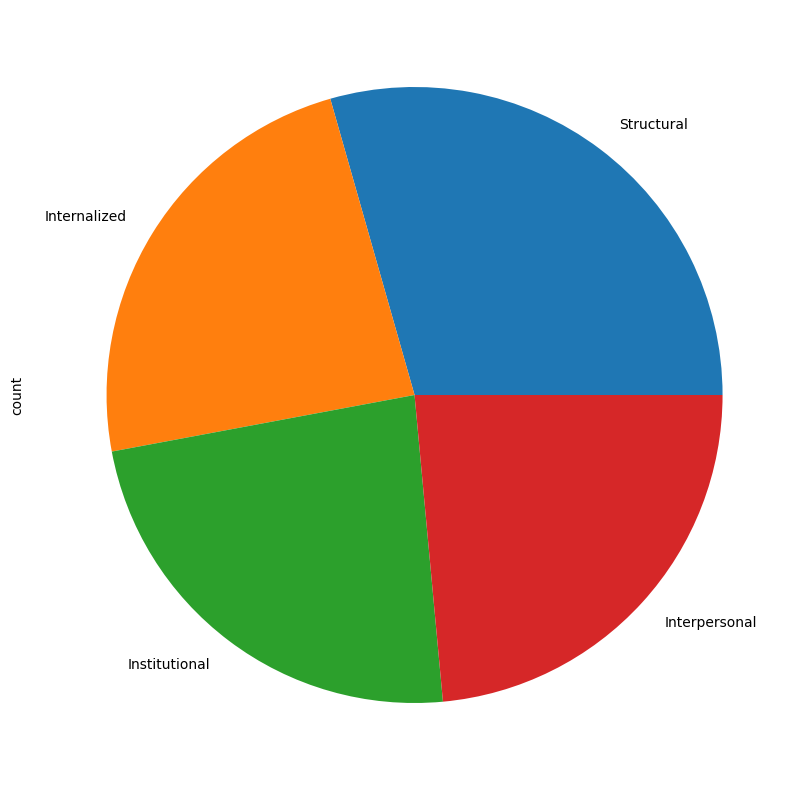

In [25]:
df.Racism.value_counts().plot(kind='pie', figsize=(10,10))

In [26]:
num_labels = 4  # Set this to the number of classes in your classification task
NUM_LABELS = 4

In [27]:
# to clear gpu memory
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [47]:
# DistilBert base
from transformers import DistilBertForSequenceClassification
from transformers import DistilBertTokenizer

# Initialize the model with the correct number of label
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_labels)

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias', 'classifier.we

In [29]:
from transformers import BertForSequenceClassification, BertTokenizerFast
# Bert base
# Load pre-trained DistilBERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=NUM_LABELS)

# Load pre-trained DistilBERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly i

In [30]:
# RoBERTa large
from transformers import RobertaForSequenceClassification, RobertaTokenizer

# Load pre-trained RoBERTa large model for sequence classification
model = RobertaForSequenceClassification.from_pretrained('roberta-large', num_labels=NUM_LABELS)

# Load pre-trained RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')


Some weights of the model checkpoint at roberta-large were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should 

In [31]:
# Bert large
from transformers import BertForSequenceClassification, BertTokenizer

# Load pre-trained BERT large model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-large-uncased', num_labels=NUM_LABELS)

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')


Some weights of the model checkpoint at bert-large-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly

In [32]:
# deberta large
from transformers import DebertaForSequenceClassification, DebertaTokenizer

# Load pre-trained DeBERTa large model for sequence classification
model = DebertaForSequenceClassification.from_pretrained('microsoft/deberta-large', num_labels=NUM_LABELS)

# Load pre-trained DeBERTa tokenizer
tokenizer = DebertaTokenizer.from_pretrained('microsoft/deberta-large')


C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\modeling_utils.py:415: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file,

In [33]:
model.to(device)

DebertaForSequenceClassification(
  (deberta): DebertaModel(
    (embeddings): DebertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=0)
      (LayerNorm): DebertaLayerNorm()
      (dropout): StableDropout()
    )
    (encoder): DebertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x DebertaLayer(
          (attention): DebertaAttention(
            (self): DisentangledSelfAttention(
              (in_proj): Linear(in_features=1024, out_features=3072, bias=False)
              (pos_dropout): StableDropout()
              (pos_proj): Linear(in_features=1024, out_features=1024, bias=False)
              (pos_q_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): StableDropout()
            )
            (output): DebertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): DebertaLayerNorm()
              (dropout): StableDropout()
            )
          )
   

In [34]:
SIZE= df.shape[0]

pivot = int(len(df)*3/4)

train_texts= list(df.Experience[:pivot])

val_texts=   list(df.Experience[pivot:])

train_labels= list(df.labels[:pivot])

val_labels=   list(df.labels[pivot: ])

In [35]:
len(train_texts)

63

In [36]:
len(train_texts), len(val_texts)

(63, 22)

In [46]:
train_texts

['Certain students experience a lack of self-worth in academic settings, feeling that they are not entitled to success or recognition due to internalized racism.',
 'Students at our university often struggle to find affordable housing near campus, which leads to long commutes and additional stress.',
 'Some students express a lack of belief in their own potential, feeling resigned to lower expectations due to pervasive stereotypes about their racial or cultural identity.',
 'The emphasis on competitive academic environments can exacerbate feelings of inadequacy among students from marginalized backgrounds, impacting their performance.',
 "The lack of affordable and reliable transportation options limits students' ability to attend classes regularly and participate in campus activities.",
 'Students sometimes express a belief that they will always be judged or evaluated based on their racial background, leading to feelings of frustration and hopelessness.',
 'The financial aid system is

In [48]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings  = tokenizer(val_texts, truncation=True, padding=True)


In [57]:
train_encodings

{'input_ids': [[101, 3056, 2493, 3325, 1037, 3768, 1997, 2969, 1011, 4276, 1999, 3834, 10906, 1010, 3110, 2008, 2027, 2024, 2025, 4709, 2000, 3112, 2030, 5038, 2349, 2000, 4722, 3550, 14398, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2493, 2012, 2256, 2118, 2411, 5998, 2000, 2424, 15184, 3847, 2379, 3721, 1010, 2029, 5260, 2000, 2146, 4012, 26746, 2015, 1998, 3176, 6911, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2070, 2493, 4671, 1037, 3768, 1997, 6772, 1999, 2037, 2219, 4022, 1010, 3110, 5295, 2000, 2896, 10908, 2349, 2000, 2566, 12044, 3512, 22807, 2055, 2037, 5762, 2030, 3451, 4767, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [49]:
class DataLoader(Dataset):
    """
    Custom Dataset class for handling tokenized text data and corresponding labels.
    Inherits from torch.utils.data.Dataset.
    """
    def __init__(self, encodings, labels):
        """
        Initializes the DataLoader class with encodings and labels.

        Args:
            encodings (dict): A dictionary containing tokenized input text data
                              (e.g., 'input_ids', 'token_type_ids', 'attention_mask').
            labels (list): A list of integer labels for the input text data.
        """
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        """
        Returns a dictionary containing tokenized data and the corresponding label for a given index.

        Args:
            idx (int): The index of the data item to retrieve.

        Returns:
            item (dict): A dictionary containing the tokenized data and the corresponding label.
        """
        # Retrieve tokenized data for the given index
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the label for the given index to the item dictionary
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        """
        Returns the number of data items in the dataset.

        Returns:
            (int): The number of data items in the dataset.
        """
        return len(self.labels)

In [50]:
train_dataloader = DataLoader(train_encodings, train_labels)

val_dataloader = DataLoader(val_encodings, val_labels)

In [51]:
train_dataloader[0]

{'input_ids': tensor([  101,  3056,  2493,  3325,  1037,  3768,  1997,  2969,  1011,  4276,
          1999,  3834, 10906,  1010,  3110,  2008,  2027,  2024,  2025,  4709,
          2000,  3112,  2030,  5038,  2349,  2000,  4722,  3550, 14398,  1012,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'labels': tensor(

In [52]:
from transformers import TrainingArguments, Trainer

In [53]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    """
    Computes accuracy, F1, precision, and recall for a given set of predictions.
    
    Args:
        pred (obj): An object containing label_ids and predictions attributes.
            - label_ids (array-like): A 1D array of true class labels.
            - predictions (array-like): A 2D array where each row represents
              an observation, and each column represents the probability of 
              that observation belonging to a certain class.
              
    Returns:
        dict: A dictionary containing the following metrics:
            - Accuracy (float): The proportion of correctly classified instances.
            - F1 (float): The macro F1 score, which is the harmonic mean of precision
              and recall. Macro averaging calculates the metric independently for
              each class and then takes the average.
            - Precision (float): The macro precision, which is the number of true
              positives divided by the sum of true positives and false positives.
            - Recall (float): The macro recall, which is the number of true positives
              divided by the sum of true positives and false negatives.
    """
    # Extract true labels from the input object
    labels = pred.label_ids
    
    # Obtain predicted class labels by finding the column index with the maximum probability
    preds = pred.predictions.argmax(-1)
    
    # Compute macro precision, recall, and F1 score using sklearn's precision_recall_fscore_support function
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    
    # Calculate the accuracy score using sklearn's accuracy_score function
    acc = accuracy_score(labels, preds)
    
    # Return the computed metrics as a dictionary
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

In [54]:
training_args = TrainingArguments(
    # The output directory where the model predictions and checkpoints will be written
    output_dir='./TTC4900Model', 
    do_train=True,
    do_eval=True,
    #  The number of epochs, defaults to 3.0 
    num_train_epochs=50,              
    per_device_train_batch_size=4,  
    per_device_eval_batch_size=4,
    learning_rate=1e-5,
    # Number of steps used for a linear warmup
    warmup_steps=500,                
    weight_decay=0.01,
    logging_strategy='steps',
   # TensorBoard log directory                 
    logging_dir='./multi-class-logs',            
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=10,
    save_strategy="steps", 
    fp16=True,
    load_best_model_at_end=True
)

In [55]:
trainer = Trainer(
    # the pre-trained model that will be fine-tuned 
    model=model,
     # training arguments that we defined above                        
    args=training_args,                 
    train_dataset=train_dataloader,         
    eval_dataset=val_dataloader,            
    compute_metrics= compute_metrics
)

Using cuda_amp half precision backend
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:593: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [56]:
trainer.train()

C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 63
  Num Epochs = 50
  Instantaneous batch size per device = 4
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 1
  Total optimization steps = 800
  Number of trainable parameters = 66956548
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
10,1.406000,1.389071,0.181818,0.083333,0.058824,0.142857
20,1.395600,1.388583,0.181818,0.083333,0.058824,0.142857
30,1.392000,1.387695,0.181818,0.083333,0.058824,0.142857
40,1.403900,1.386808,0.181818,0.083333,0.058824,0.142857
50,1.389100,1.385210,0.227273,0.100000,0.069444,0.178571
60,1.392200,1.382857,0.227273,0.100000,0.069444,0.178571
70,1.392100,1.381348,0.227273,0.100000,0.069444,0.178571
80,1.402800,1.379350,0.181818,0.095238,0.071429,0.142857
90,1.380200,1.376953,0.136364,0.083333,0.068182,0.107143
100,1.379200,1.373358,0.181818,0.125000,0.094017,0.238095


***** Running Evaluation *****
  Num examples = 22
  Batch size = 4
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
***** Running Evaluation *****
  Num examples = 22
  Batch size = 4
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

KeyboardInterrupt: 

In [ ]:
q=[trainer.evaluate(eval_dataset=df_org) for df_org in [train_dataloader, val_dataloader]]

pd.DataFrame(q, index=["train","val"]).iloc[:,:5]

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
def predict(text):
    """
    Predicts the class label for a given input text

    Args:
        text (str): The input text for which the class label needs to be predicted.

    Returns:
        probs (torch.Tensor): Class probabilities for the input text.
        pred_label_idx (torch.Tensor): The index of the predicted class label.
        pred_label (str): The predicted class label.
    """
    # Tokenize the input text and move tensors to the GPU if available
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to("cuda")

    # Get model output (logits)
    outputs = model(**inputs)

    probs = outputs[0].softmax(1)
    """ Explanation outputs: The BERT model returns a tuple containing the output logits (and possibly other elements depending on the model configuration). In this case, the output logits are the first element in the tuple, which is why we access it using outputs[0].

    outputs[0]: This is a tensor containing the raw output logits for each class. The shape of the tensor is (batch_size, num_classes) where batch_size is the number of input samples (in this case, 1, as we are predicting for a single input text) and num_classes is the number of target classes.

    softmax(1): The softmax function is applied along dimension 1 (the class dimension) to convert the raw logits into class probabilities. Softmax normalizes the logits so that they sum to 1, making them interpretable as probabilities. """

    # Get the index of the class with the highest probability
    # argmax() finds the index of the maximum value in the tensor along a specified dimension.
    # By default, if no dimension is specified, it returns the index of the maximum value in the flattened tensor.
    pred_label_idx = probs.argmax()

    # Now map the predicted class index to the actual class label 
    # Since pred_label_idx is a tensor containing a single value (the predicted class index), 
    # the .item() method is used to extract the value as a scalar
    pred_label = model.config.id2label[pred_label_idx.item()]

    return probs, pred_label_idx, pred_label

In [ ]:
# Test with a an example text/custom prediction
# structural
text = "In our institution, structural racism manifests through policies that inadvertently disadvantage students of color, such as standardized testing requirements and lack of diverse faculty, which impacts their academic success and sense of belonging."
predict(text)

In [ ]:
# Test with a an example text/custom prediction
#institutional
text = "Institutional racism is evident in the lack of culturally relevant curriculum and support services for students from marginalized backgrounds, leading to unequal educational opportunities and outcomes."
predict(text)

In [ ]:
# Test with a an example text/custom prediction
# internalized
text = "Interpersonal racism occurs in my classroom when students make racially insensitive comments, which creates a hostile learning environment for students of color and affects their participation and engagement."
predict(text)

In [ ]:
# Test with a an example text/custom prediction
# interpersonal
text = "As a faculty member, I often find myself questioning the validity of my own experiences with racism. I sometimes feel that I’m overreacting or that my concerns aren’t significant enough to address, even when I know deep down that these are harmful thoughts ingrained from years of subtle societal messaging."
predict(text)

In [ ]:
import pandas as pd
from nltk.tokenize import sent_tokenize
from IPython.core.display import HTML, display

# Define the colors for each type of oppression using hex color codes
colors = {
    'LABEL_0': '#FFFF00',  # yellow, structural
    'LABEL_1': '#0000FF',  # blue, institutional
    'LABEL_2': '#008000',  # green, interpersonal
    'LABEL_3': '#FF0000',  # red, internalized
}

def highlight_text(text, predictions):
    """
    Highlights text based on predictions using HTML.

    Args:
        text (str): The text to be highlighted.
        predictions (list of tuples): Each tuple contains (sentence, predicted_label).

    Returns:
        str: HTML string with highlighted text.
    """
    html_text = ""
    sentences = sent_tokenize(text)
    
    for sentence in sentences:
        highlighted = False
        for sent, label in predictions:
            if sent.strip().lower() in sentence.strip().lower():
                color = colors.get(label, '#FFFFFF')  # default to white if no color found
                html_text += f'<span style="background-color: {color};">{sentence}</span> '
                highlighted = True
                break
        if not highlighted:
            html_text += f'{sentence} '
    
    return html_text.strip()


# Process and display each comment
for index, row in M2.iterrows():
    text = row['Comment']
    
    # Split text into sentences
    sentences = sent_tokenize(text)
    
    # Predict for each sentence
    predictions = [(sent, predict(sent)[2]) for sent in sentences]  # Assuming predict returns (probs, pred_label_idx, pred_label)
    
    # Generate highlighted HTML
    highlighted_html = highlight_text(text, predictions)
    
    # Display highlighted HTML using IPython
    display(HTML(f"<h3>Comment {index + 1}</h3><p>{highlighted_html}</p>"))
